<a href="https://colab.research.google.com/github/indu00729/BloodCell/blob/main/RBC_CLASSIFICATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Install patool to extract .rar files
!pip install patool
import patoolib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.4/101.4 kB 8.6 MB/s eta 0:00:00


In [ ]:
# Define paths
rar_path = '/content/RBC.rar'
extract_path = '/content/extracted_images'

# Create extraction directory
if not os.path.exists(extract_path):
    os.makedirs(extract_path)

# Extract the RAR file
patoolib.extract_archive(rar_path, outdir=extract_path)

INFO patool: Extracting /content/RBC.rar ...
INFO patool: running /usr/bin/unrar x -kb -or -- /content/RBC.rar
INFO patool: ... /content/RBC.rar extracted to `/content/extracted_images'.


'/content/extracted_images'

In [ ]:
import os

# Path where the RAR was extracted
extract_path = '/content/extracted_images'
rbc_path = os.path.join(extract_path, 'RBC')

# Identify classes (subdirectories)
path_to_check = rbc_path if os.path.exists(rbc_path) else extract_path
classes = [d for d in os.listdir(path_to_check) if os.path.isdir(os.path.join(path_to_check, d))]

print(f"Found {len(classes)} classes in {path_to_check}:")
for cls in sorted(classes):
    print(f" - {cls}")

Found 3 classes in /content/extracted_images/RBC:
 - test
 - train
 - val


In [ ]:
# List the actual classes found inside the split directories
classes_dir = os.path.join(path_to_check, 'train')
if os.path.exists(classes_dir):
    actual_classes = [d for d in os.listdir(classes_dir) if os.path.isdir(os.path.join(classes_dir, d))]
    print(f"Class types found in the dataset:")
    for c in sorted(actual_classes):
        print(f" - {c}")
else:
    print("Could not find a 'train' directory to list classes from.")

Class types found in the dataset:
 - Acanthocyte
 - Burr cell
 - Hypochromia
 - Ovalocyte
 - Schistocyte
 - Spherocyte
 - Stomatocyte
 - Target Cell
 - cigar cell
 - normal
 - teardrop


### Clinical Significance of Class Labels
The labels in this dataset correspond to specific Red Blood Cell (RBC) morphologies that are clinical indicators for various conditions:

1.  **Normal**: Healthy, biconcave disc-shaped RBCs.
2.  **Acanthocyte**: Spiky cells often associated with liver disease or abetalipoproteinemia.
3.  **Burr cell (Echinocyte)**: Cells with small, regular projections; often seen in kidney disease (uremia) or dehydration.
4.  **Hypochromia**: Pale cells with less hemoglobin, typically indicating Iron Deficiency Anemia.
5.  **Ovalocyte / Elliptocyte**: Oval-shaped cells seen in Hereditary Elliptocytosis or various anemias.
6.  **Schistocyte**: Fragmented cells indicating mechanical damage, often seen in Microangiopathic Hemolytic Anemia (MAHA).
7.  **Spherocyte**: Sphere-shaped cells seen in Hereditary Spherocytosis or Immune Hemolytic Anemia.
8.  **Stomatocyte**: Cells with a mouth-like central pallor, associated with hereditary conditions or alcoholism.
9.  **Target Cell (Codocyte)**: Resembling a bullseye; common in Thalassemia, liver disease, or post-splenectomy.
10. **Cigar cell**: A subtype of elliptocyte, often associated with severe Iron Deficiency Anemia.
11. **Teardrop (Dacrocyte)**: Shaped like a drop, frequently seen in Myelofibrosis or bone marrow disorders.

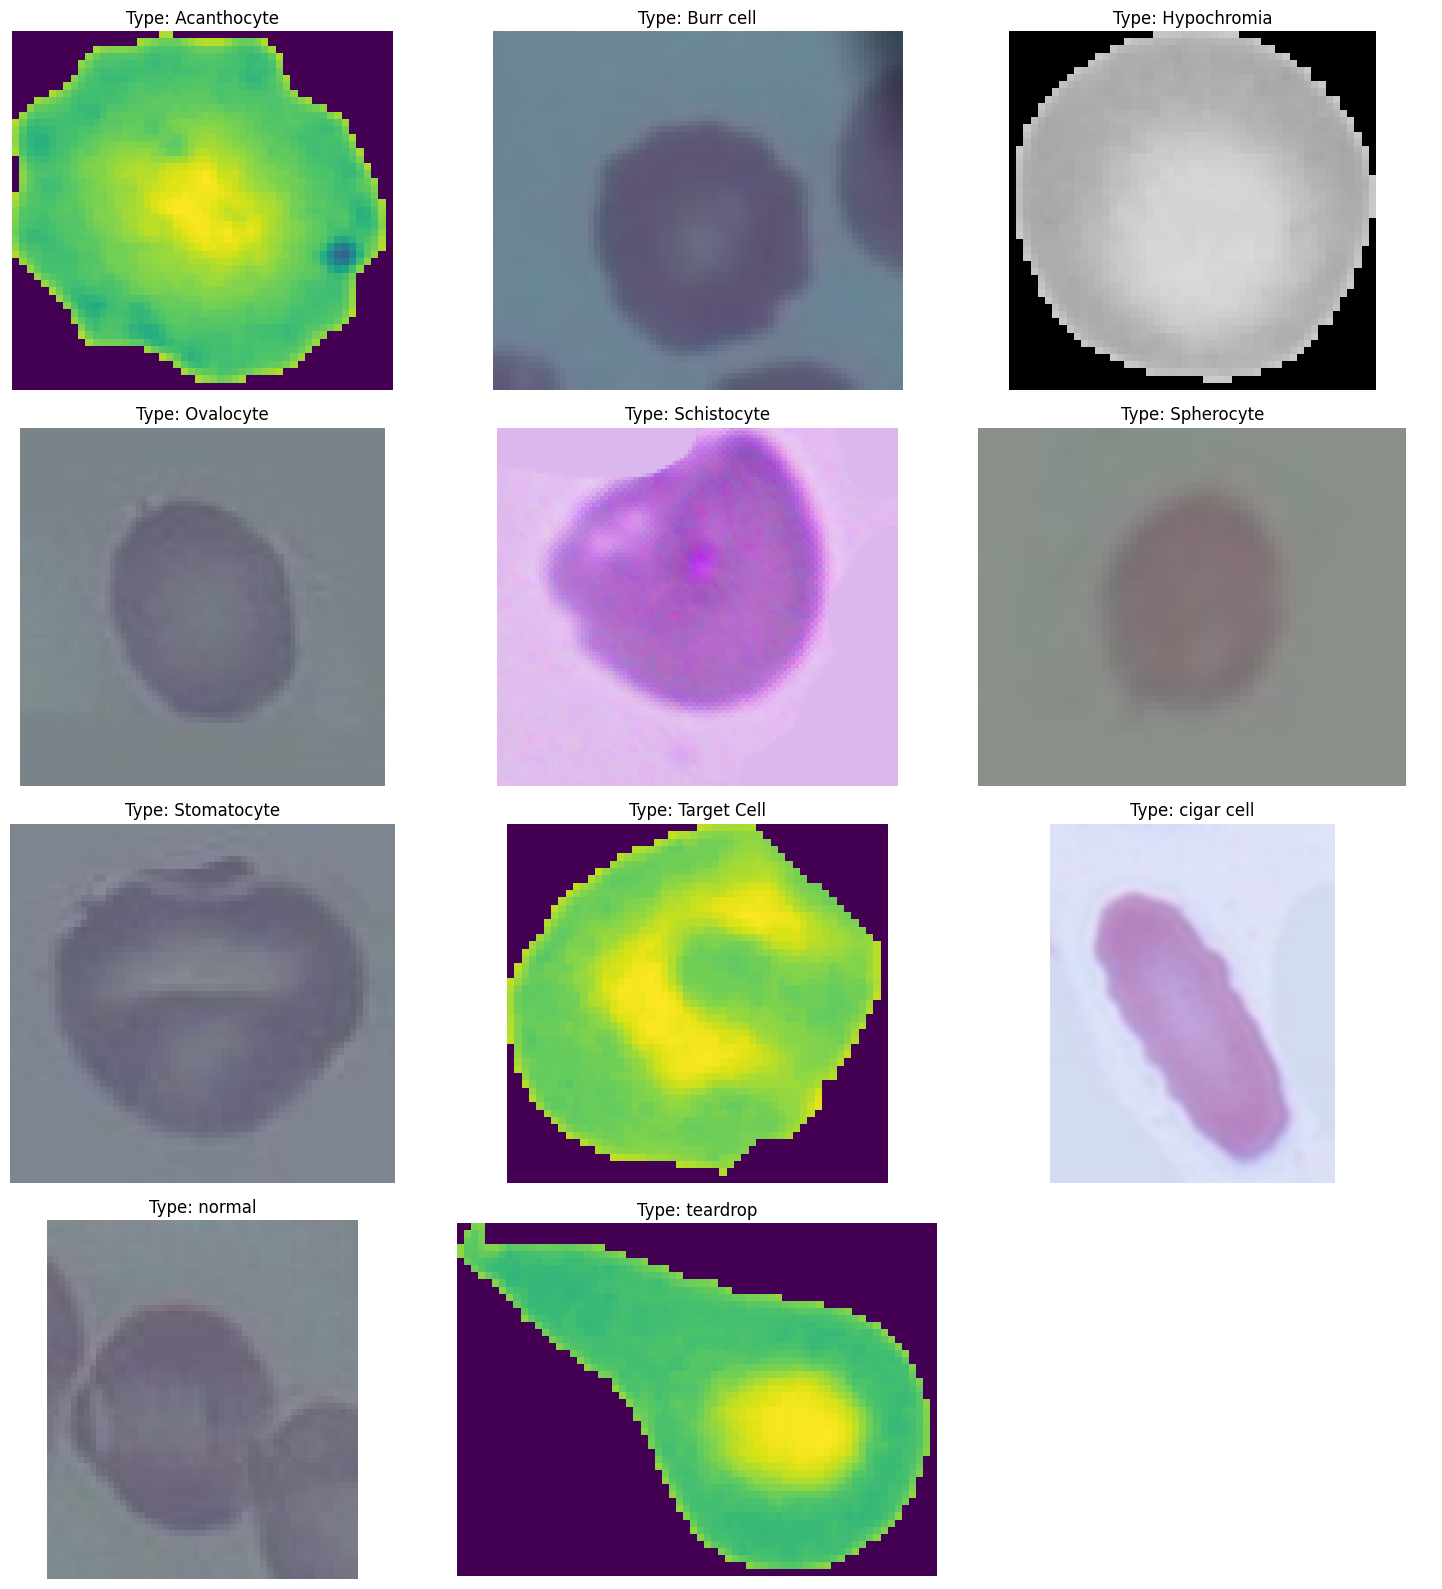

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import math

# We'll look into the train folder for samples
samples_dir = os.path.join(path_to_check, 'train')
classes = sorted([d for d in os.listdir(samples_dir) if os.path.isdir(os.path.join(samples_dir, d))])

# Setup the grid
cols = 3
rows = math.ceil(len(classes) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = axes.flatten()

for i, cls in enumerate(classes):
    cls_path = os.path.join(samples_dir, cls)
    img_files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if img_files:
        img_path = os.path.join(cls_path, img_files[0])
        img = mpimg.imread(img_path)
        axes[i].imshow(img)
        axes[i].set_title(f"Type: {cls}")
        axes[i].axis('off')
    else:
        axes[i].text(0.5, 0.5, f"No images in {cls}", ha='center')
        axes[i].axis('off')

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### 1. Data Preparation
We will use `tf.keras.utils.image_dataset_from_directory` to load the images. We'll set a standard image size (e.g., 128x128) and batch size.

In [ ]:
import tensorflow as tf

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Define directory paths based on the previous extraction
train_path = '/content/extracted_images/RBC/train'
val_path = '/content/extracted_images/RBC/val'
test_path = '/content/extracted_images/RBC/test'

# Load datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

class_names = train_ds.class_names
print(f"Loaded classes: {class_names}")

Found 19940 files belonging to 11 classes.
Found 3158 files belonging to 11 classes.
Found 6240 files belonging to 11 classes.
Loaded classes: ['Acanthocyte', 'Burr cell', 'Hypochromia', 'Ovalocyte', 'Schistocyte', 'Spherocyte', 'Stomatocyte', 'Target Cell', 'cigar cell', 'normal', 'teardrop']


### 2. Model Definition
Now, we'll define a simple Convolutional Neural Network (CNN). We include a rescaling layer to normalize pixel values between 0 and 1.

In [ ]:
from tensorflow.keras import layers, models

num_classes = len(class_names)

model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,306,059 (12.61 MB)

 Trainable params: 3,306,059 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.6122 - loss: 1.1450 - val_accuracy: 0.7597 - val_loss: 0.8037
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.7903 - loss: 0.6506 - val_accuracy: 0.8144 - val_loss: 0.5903
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.8081 - loss: 0.5739 - val_accuracy: 0.8227 - val_loss: 0.5373
Epoch 4/10
 24/200 ━━━━━━━━━━━━━━━━━━━━ 24s 138ms/step - accuracy: 0.8076 - loss: 0.5361

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.8230 - loss: 0.4782 - val_accuracy: 0.7948 - val_loss: 0.6230
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.8467 - loss: 0.4401 - val_accuracy: 0.8198 - val_loss: 0.5406
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.8561 - loss: 0.4098 - val_accuracy: 0.8281 - val_loss: 0.5194
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.8602 - loss: 0.4108 - val_accuracy: 0.8350 - val_loss: 0.4780
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8595 - loss: 0.3965 - val_accuracy: 0.8420 - val_loss: 0.4859
Epoch 9/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.8811 - loss: 0.3491 - val_accuracy: 0.8388 - val_loss: 0.4864
Epoch 10/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.8880 - loss: 0.3161 - val_accuracy: 0.8619 - val_loss: 0.4328


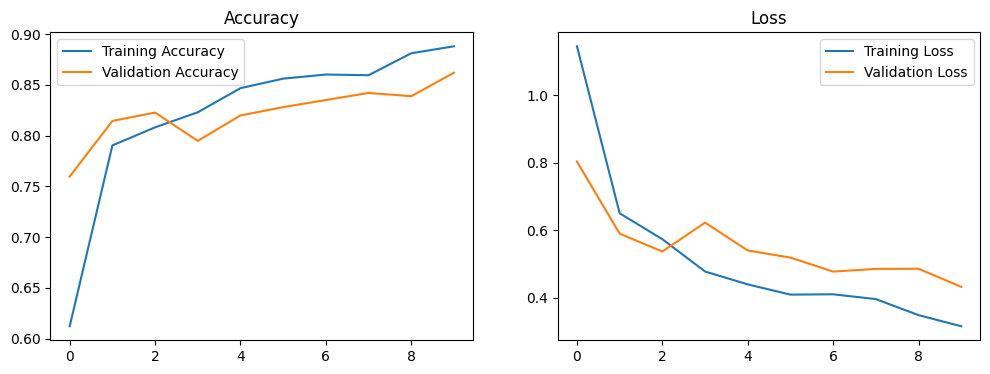

In [ ]:
EPOCHS = 10
STEPS_PER_EPOCH = 200

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH
)

# Visualize results
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss')
plt.show()

### 4. Model Evaluation
Now that the model is trained, let's evaluate its performance using the test dataset that was not used during training or validation.

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print(f'\nTest accuracy: {test_acc:.4f}')
print(f'Test loss: {test_loss:.4f}')

195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8572 - loss: 0.4405

Test accuracy: 0.8572
Test loss: 0.4405


### 5. Visualizing Real vs Predicted Labels
Let's take a sample batch from the test set and compare the model's predictions with the actual ground truth.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 559ms/step


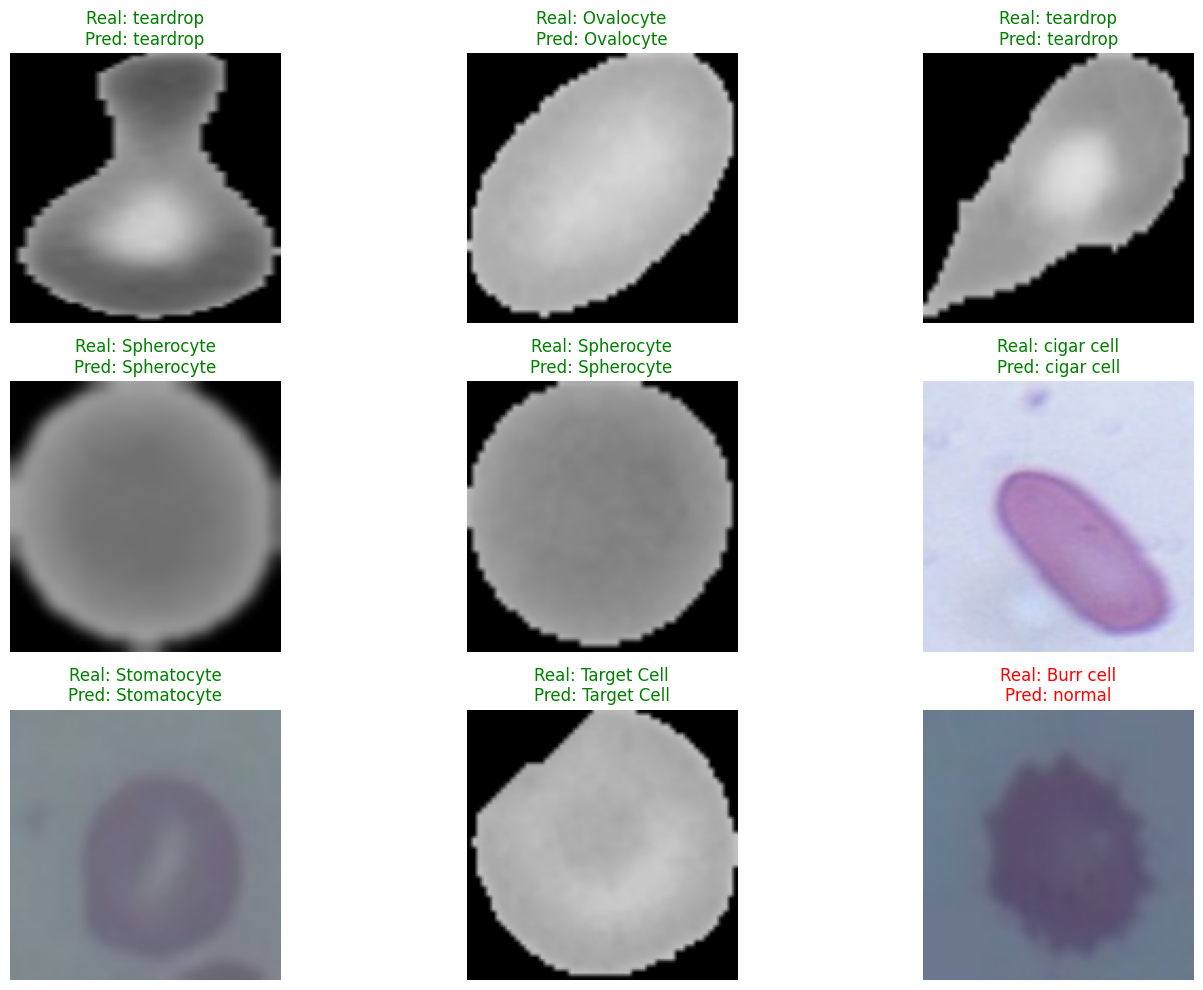

In [ ]:
import numpy as np

# Retrieve a single batch of images and labels from the test set
image_batch, label_batch = next(iter(test_ds))

# Generate predictions
predictions = model.predict(image_batch)
pred_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(label_batch, axis=1)

# Plot the results
plt.figure(figsize=(15, 10))
for i in range(9): # Display first 9 images
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image_batch[i].numpy().astype("uint8"))

    actual_name = class_names[true_labels[i]]
    predicted_name = class_names[pred_labels[i]]

    # Color green if correct, red if incorrect
    color = 'green' if actual_name == predicted_name else 'red'

    plt.title(f"Real: {actual_name}\nPred: {predicted_name}", color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()

### 6. Transfer Learning with ResNet50
We will use a pre-trained ResNet50 model as a feature extractor and train it on our RBC dataset.

In [ ]:
from tensorflow.keras.applications import ResNet50

# Base model with pre-trained weights
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_model.trainable = False  # Freeze the base model layers

# Create the new model
resnet_model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation='softmax')
])

resnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 11)             │         2,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,115,083 (91.99 MB)

 Trainable params: 527,371 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
RESNET_EPOCHS = 10
RESNET_STEPS = 200

history_resnet = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=RESNET_EPOCHS,
    steps_per_epoch=RESNET_STEPS
)

# Evaluate ResNet on test set
resnet_test_loss, resnet_test_acc = resnet_model.evaluate(test_ds)
print(f'\nResNet Test accuracy: {resnet_test_acc:.4f}')

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 29s 85ms/step - accuracy: 0.2875 - loss: 2.1001 - val_accuracy: 0.2454 - val_loss: 2.0072
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - accuracy: 0.3683 - loss: 1.8726 - val_accuracy: 0.3800 - val_loss: 1.8151
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 12s 59ms/step - accuracy: 0.4358 - loss: 1.6835 - val_accuracy: 0.3955 - val_loss: 1.6740
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - accuracy: 0.4730 - loss: 1.5799 - val_accuracy: 0.4183 - val_loss: 1.6676
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - accuracy: 0.4803 - loss: 1.5370 - val_accuracy: 0.4145 - val_loss: 1.5758
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.4948 - loss: 1.4933 - val_accuracy: 0.4778 - val_loss: 1.5363
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - accuracy: 0.5008 - loss: 1.4439 - val_accuracy: 0.5431 - val_loss: 1.5051
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.5595 - loss: 1.3195 - val

### 7. ResNet50: Real vs Predicted
Let's visualize the results for the ResNet50 model on a sample batch from the test set.

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


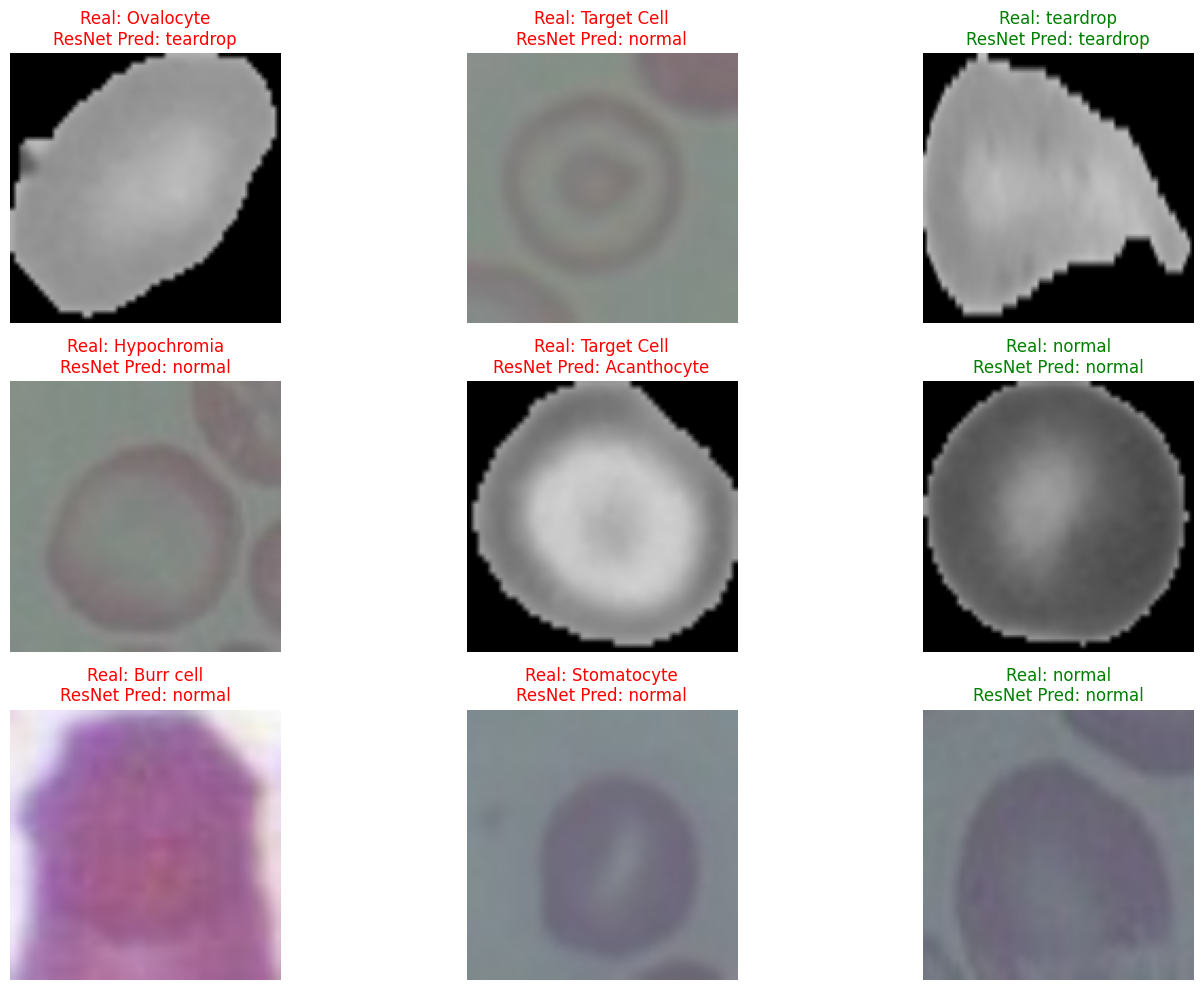

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Get a batch from test_ds
image_batch, label_batch = next(iter(test_ds))

# Predict using ResNet
resnet_predictions = resnet_model.predict(image_batch)
resnet_pred_labels = np.argmax(resnet_predictions, axis=1)
true_labels = np.argmax(label_batch, axis=1)

plt.figure(figsize=(15, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image_batch[i].numpy().astype("uint8"))

    actual_name = class_names[true_labels[i]]
    predicted_name = class_names[resnet_pred_labels[i]]

    color = 'green' if actual_name == predicted_name else 'red'

    plt.title(f"Real: {actual_name}\nResNet Pred: {predicted_name}", color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()

### 7. ResNet50: Real vs Predicted
Let's visualize the results for the ResNet50 model.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


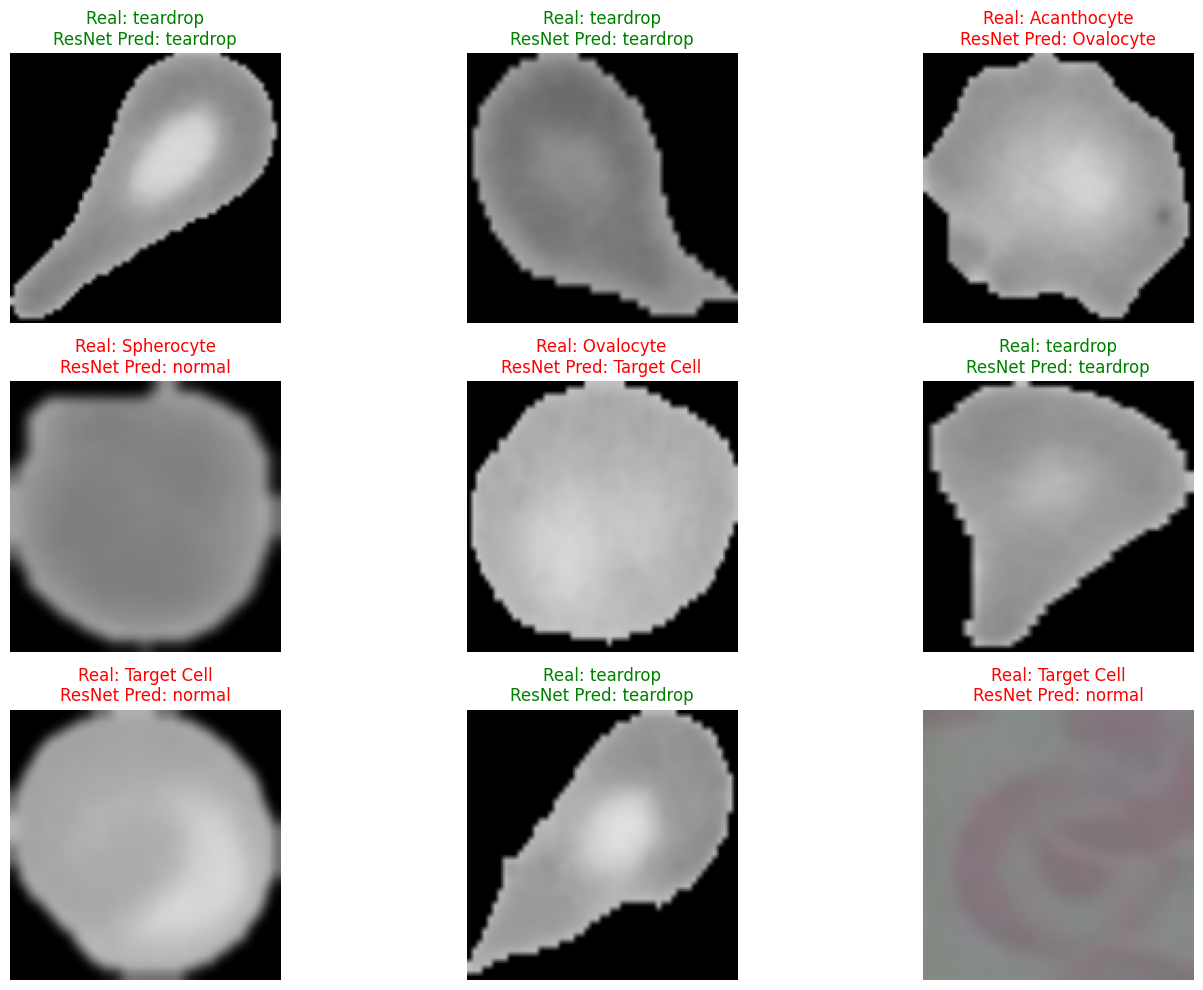

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Get a batch from test_ds
image_batch, label_batch = next(iter(test_ds))

# Predict using ResNet
resnet_predictions = resnet_model.predict(image_batch)
resnet_pred_labels = np.argmax(resnet_predictions, axis=1)
true_labels = np.argmax(label_batch, axis=1)

plt.figure(figsize=(15, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image_batch[i].numpy().astype("uint8"))

    actual_name = class_names[true_labels[i]]
    predicted_name = class_names[resnet_pred_labels[i]]

    color = 'green' if actual_name == predicted_name else 'red'

    plt.title(f"Real: {actual_name}\nResNet Pred: {predicted_name}", color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()

### 8. Saving Models and Dataset
We will save the models to the local environment and create a zip archive of the extracted images.

In [ ]:
# Save the models
model.save('rbc_cnn_model.keras')
resnet_model.save('rbc_resnet_model.keras')

print("Models saved as 'rbc_cnn_model.keras' and 'rbc_resnet_model.keras'")

# Zip the extracted dataset
import shutil
# The directory we want to zip is /content/extracted_images/RBC
shutil.make_archive('rbc_dataset_backup', 'zip', '/content/extracted_images/RBC')

print("Dataset compressed into 'rbc_dataset_backup.zip'")

Models saved as 'rbc_cnn_model.keras' and 'rbc_resnet_model.keras'
Dataset compressed into 'rbc_dataset_backup.zip'


### 13. Image Enhancement and Retraining
We will define a preprocessing function to apply CLAHE enhancement to the images and then retrain our CNN model to see if performance improves.

In [ ]:
import cv2
import numpy as np
import tensorflow as tf

def enhance_image(image):
    # image is a single image tensor from the batch
    img_np = image.numpy().astype(np.uint8)

    # Handle grayscale images by converting to RGB first
    if len(img_np.shape) == 2 or img_np.shape[2] == 1:
        img_np = cv2.cvtColor(img_np, cv2.COLOR_GRAY2RGB)
    elif img_np.shape[2] == 4:
        img_np = cv2.cvtColor(img_np, cv2.COLOR_RGBA2RGB)

    # Convert to LAB to apply CLAHE on the Luminance channel
    lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    cl = clahe.apply(l)

    limg = cv2.merge((cl,a,b))
    enhanced = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
    return enhanced.astype(np.float32)

# Helper to apply the py_function to a batch
def process_batch(images, labels):
    enhanced_images = tf.map_fn(lambda img: tf.py_function(enhance_image, [img], tf.float32), images, dtype=tf.float32)
    return enhanced_images, labels

# Map enhancement to datasets
train_ds_enhanced = train_ds.map(process_batch)
val_ds_enhanced = val_ds.map(process_batch)
test_ds_enhanced = test_ds.map(process_batch)

# Ensure shapes are correctly set for Keras
def set_shapes(img, label):
    img.set_shape((None, 128, 128, 3))
    label.set_shape((None, 11))
    return img, label

train_ds_enhanced = train_ds_enhanced.map(set_shapes)
val_ds_enhanced = val_ds_enhanced.map(set_shapes)
test_ds_enhanced = test_ds_enhanced.map(set_shapes)

Instructions for updating:
Use fn_output_signature instead


In [ ]:
# Re-initialize and train the CNN model with enhanced data
model_enhanced = models.clone_model(model)
model_enhanced.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Starting training on enhanced images...")
history_enhanced = model_enhanced.fit(
    train_ds_enhanced,
    validation_data=val_ds_enhanced,
    epochs=10,
    steps_per_epoch=200
)

# Final evaluation
final_loss, final_acc = model_enhanced.evaluate(test_ds_enhanced)
print(f'\nEnhanced Test accuracy: {final_acc:.4f}')

Starting training on enhanced images...
Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 26s 114ms/step - accuracy: 0.6427 - loss: 1.0759 - val_accuracy: 0.7654 - val_loss: 0.7510
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 25s 127ms/step - accuracy: 0.8097 - loss: 0.5770 - val_accuracy: 0.7945 - val_loss: 0.6402
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 25s 126ms/step - accuracy: 0.8453 - loss: 0.4862 - val_accuracy: 0.8458 - val_loss: 0.4999
Epoch 4/10
 24/200 ━━━━━━━━━━━━━━━━━━━━ 19s 112ms/step - accuracy: 0.8508 - loss: 0.4472

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - accuracy: 0.8527 - loss: 0.4328 - val_accuracy: 0.7888 - val_loss: 0.6546
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 21s 104ms/step - accuracy: 0.8712 - loss: 0.3801 - val_accuracy: 0.8594 - val_loss: 0.4489
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 24s 118ms/step - accuracy: 0.8828 - loss: 0.3532 - val_accuracy: 0.8505 - val_loss: 0.4645
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 22s 108ms/step - accuracy: 0.8916 - loss: 0.3316 - val_accuracy: 0.8683 - val_loss: 0.4076
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 58ms/step - accuracy: 0.9095 - loss: 0.2728 - val_accuracy: 0.8445 - val_loss: 0.5354
Epoch 9/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 22s 108ms/step - accuracy: 0.9062 - loss: 0.2701 - val_accuracy: 0.8651 - val_loss: 0.4266
Epoch 10/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 21s 106ms/step - accuracy: 0.9102 - loss: 0.2673 - val_accuracy: 0.8680 - val_loss: 0.4380
195/195 ━━━━━━━━━━━━━━━━━━━━ 13s 64ms/step - accuracy: 0.8659 - loss: 0.4177

Enhanced Test acc

### 14. Comparative Analysis: Pre vs. Post Enhancement
We compare the training metrics and final test accuracy of the baseline CNN against the CNN trained on CLAHE-enhanced images.

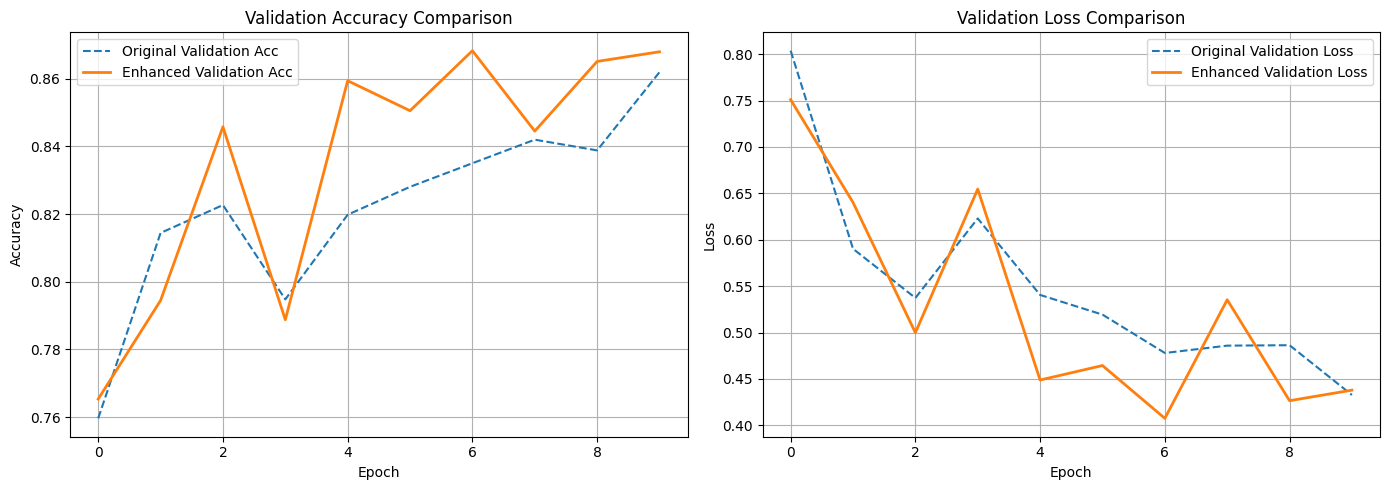

,Metric,Original Model,Enhanced Model
0,Test Accuracy,0.8572,0.8659
1,Test Loss,0.4405,0.4177


In [ ]:
import matplotlib.pyplot as plt

# Plotting Accuracy Comparison
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['val_accuracy'], label='Original Validation Acc', linestyle='--')
plt.plot(history_enhanced.history['val_accuracy'], label='Enhanced Validation Acc', linewidth=2)
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plotting Loss Comparison
plt.subplot(1, 2, 2)
plt.plot(history.history['val_loss'], label='Original Validation Loss', linestyle='--')
plt.plot(history_enhanced.history['val_loss'], label='Enhanced Validation Loss', linewidth=2)
plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Summary Table
comparison_data = {
    'Metric': ['Test Accuracy', 'Test Loss'],
    'Original Model': [f"{test_acc:.4f}", f"{test_loss:.4f}"],
    'Enhanced Model': [f"{final_acc:.4f}", f"{final_loss:.4f}"]
}
import pandas as pd
display(pd.DataFrame(comparison_data))

### 10. Morphological Analysis
In this section, we take one representative image from each of the 11 classes and perform morphological operations to highlight their structural differences.

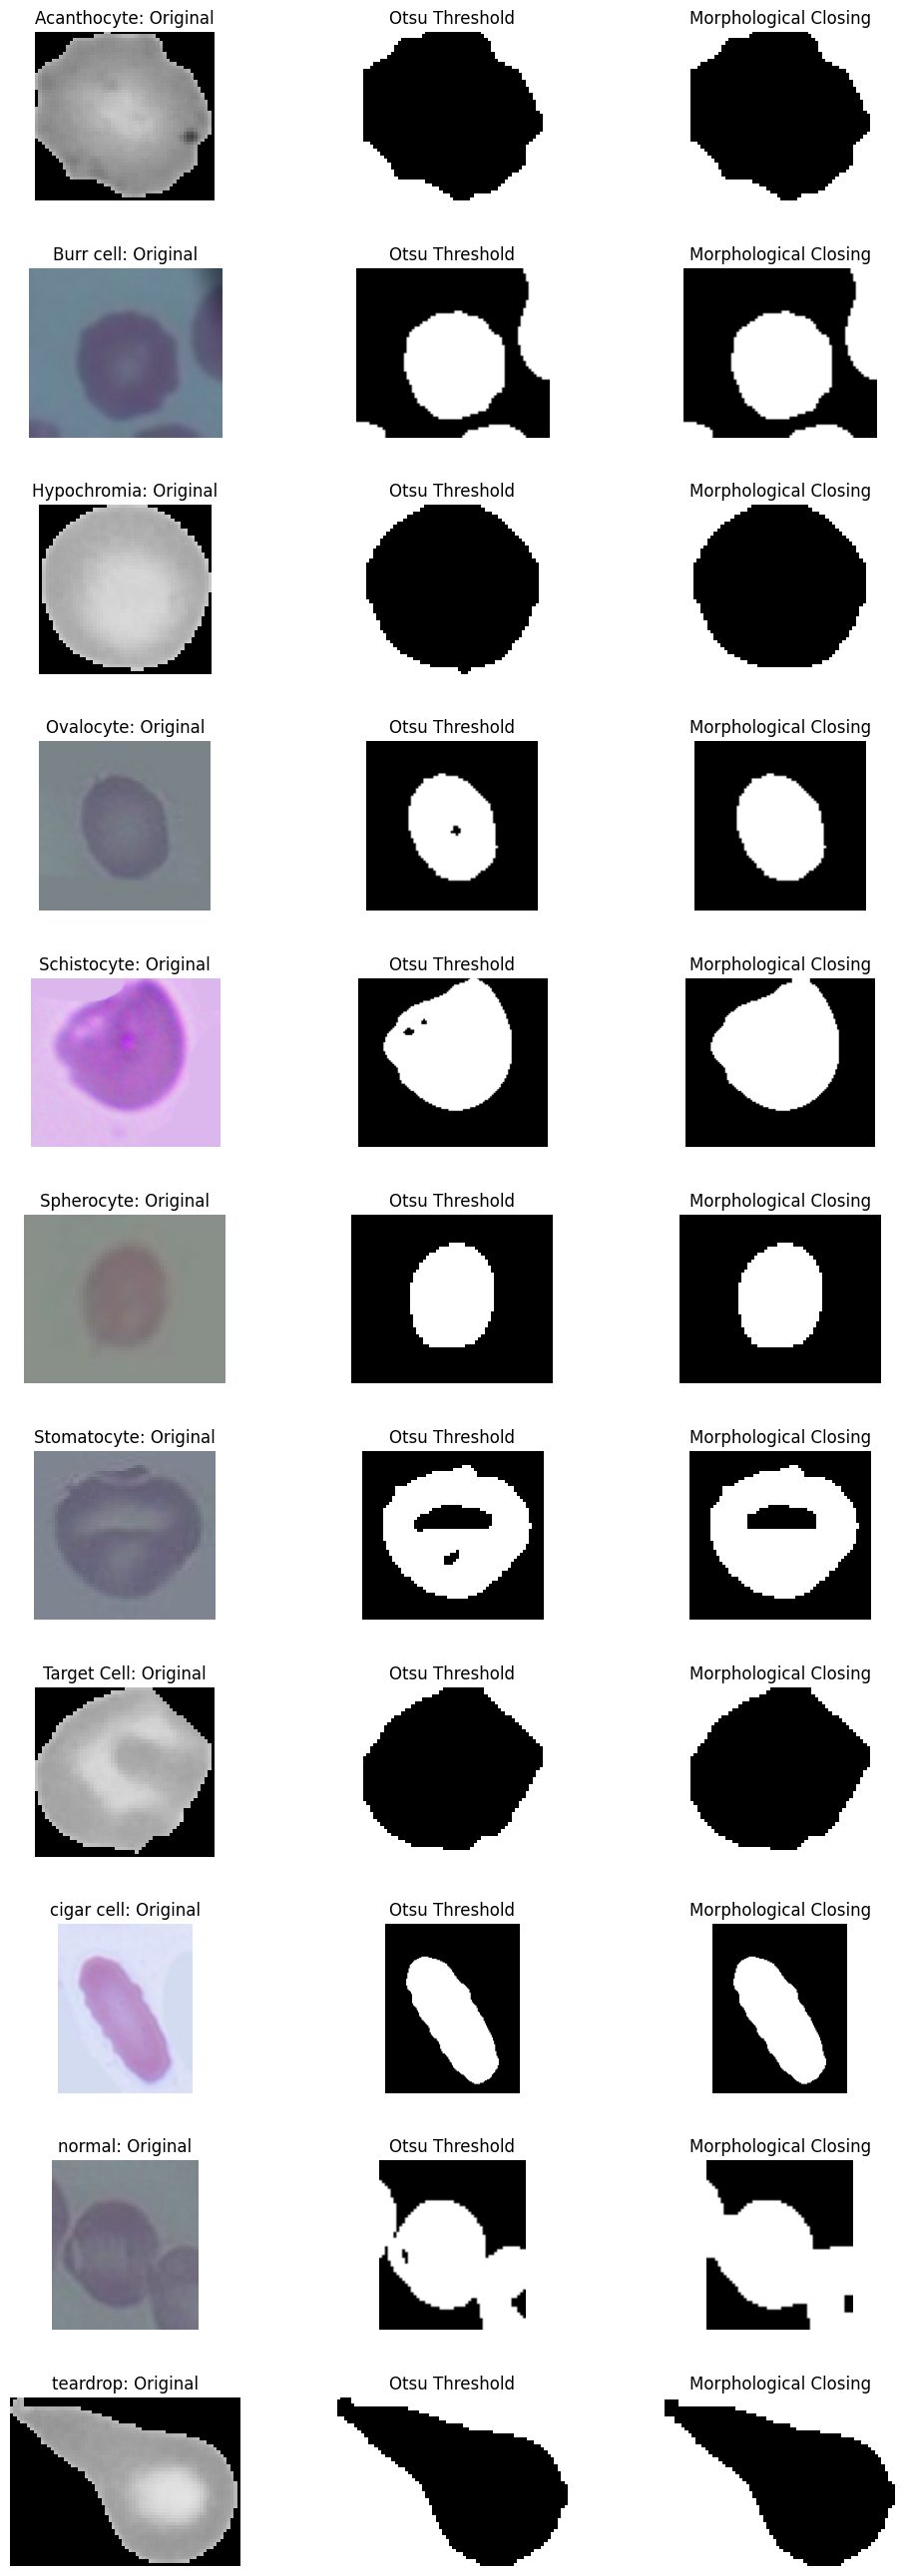

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Prepare the classes and find one sample image per class
samples_dir = '/content/extracted_images/RBC/train'
classes = sorted([d for d in os.listdir(samples_dir) if os.path.isdir(os.path.join(samples_dir, d))])

fig, axes = plt.subplots(len(classes), 3, figsize=(12, len(classes) * 3))
plt.subplots_adjust(hspace=0.4)

for i, cls in enumerate(classes):
    cls_path = os.path.join(samples_dir, cls)
    img_name = os.listdir(cls_path)[0]
    img_path = os.path.join(cls_path, img_name)

    # 1. Load Original
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 2. Pre-processing for Morphology
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # Apply Gaussian blur to reduce noise
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    # Global thresholding (Otsu's method)
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # 3. Morphological Operations (Closing to fill small holes)
    kernel = np.ones((5, 5), np.uint8)
    morph = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

    # Plotting
    axes[i, 0].imshow(img_rgb)
    axes[i, 0].set_title(f"{cls}: Original")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(thresh, cmap='gray')
    axes[i, 1].set_title("Otsu Threshold")
    axes[i, 1].axis('off')

    axes[i, 2].imshow(morph, cmap='gray')
    axes[i, 2].set_title("Morphological Closing")
    axes[i, 2].axis('off')

plt.show()

### 15. Additional Enhancement: Multi-Scale Retinex (MSR)
Retinex enhancement aims to improve the dynamic range of the image by estimating the lighting conditions. We use multiple Gaussian blurs (scales) to simulate the way the human eye perceives detail across different spatial frequencies.

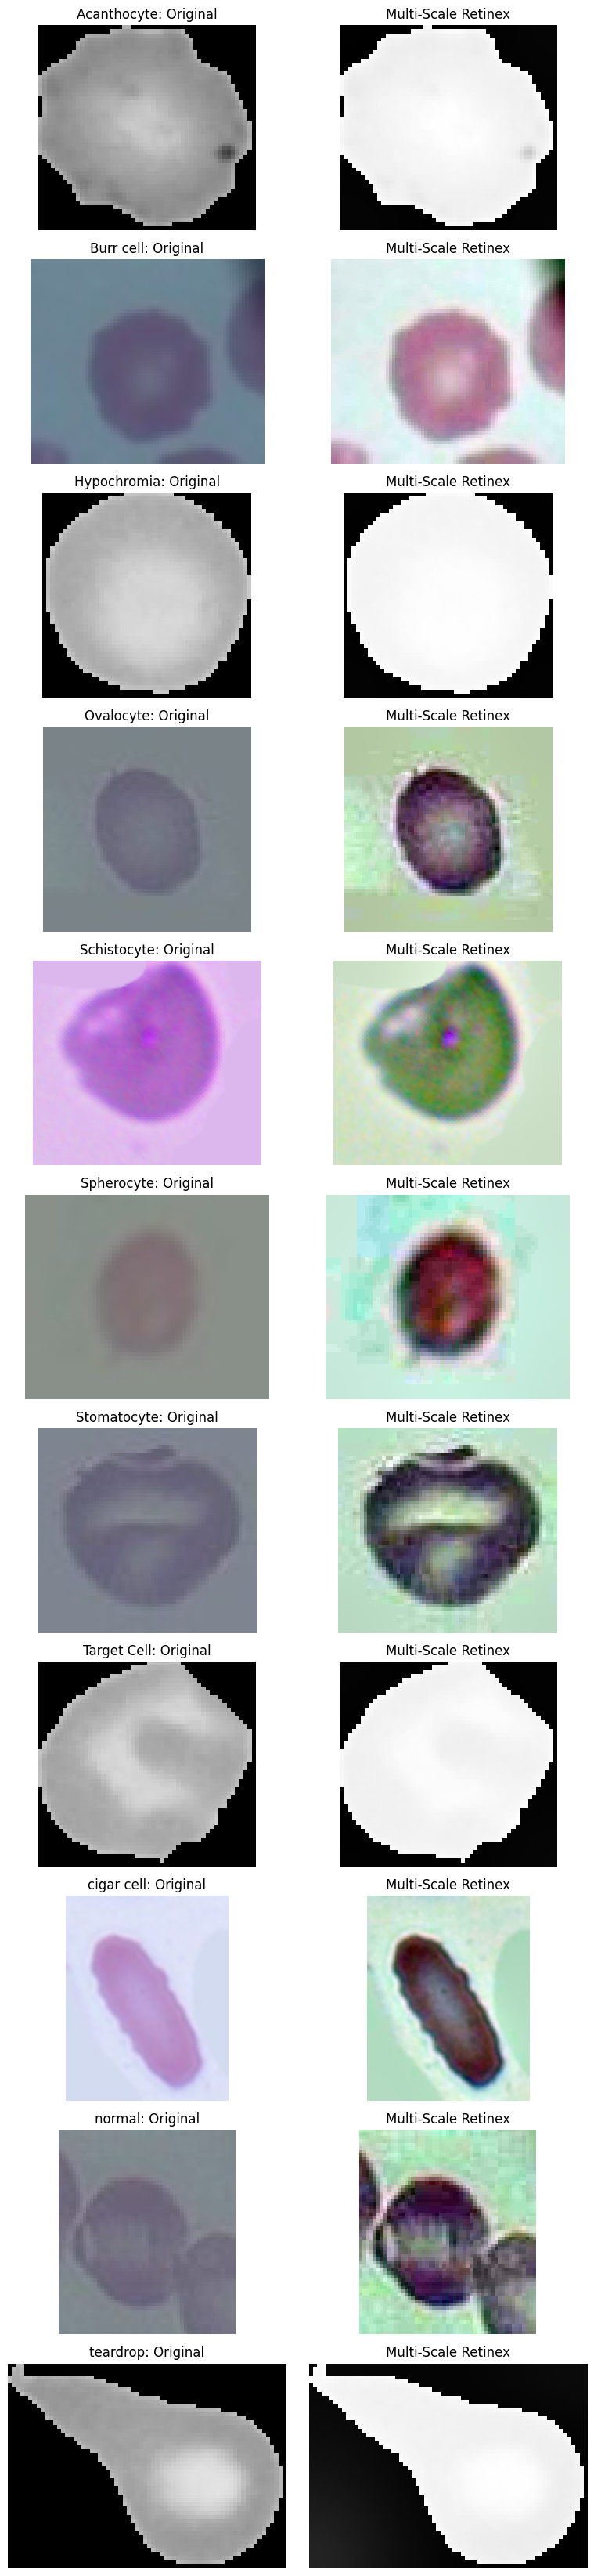

In [ ]:
def single_scale_retinex(img, sigma):
    retinex = np.log10(img.astype(np.float32) + 1.0) - np.log10(cv2.GaussianBlur(img.astype(np.float32), (0, 0), sigma) + 1.0)
    return retinex

def multi_scale_retinex(img, sigma_list):
    retinex = np.zeros_like(img, dtype=np.float32)
    for sigma in sigma_list:
        retinex += single_scale_retinex(img, sigma)
    retinex = retinex / len(sigma_list)

    # Normalize to 0-255
    retinex = cv2.normalize(retinex, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    return retinex

# Visualize MSR on samples
fig, axes = plt.subplots(len(classes), 2, figsize=(8, len(classes) * 3))

for i, cls in enumerate(classes):
    cls_path = os.path.join(samples_dir, cls)
    img_name = os.listdir(cls_path)[0]
    img_path = os.path.join(cls_path, img_name)
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Apply MSR with 3 scales
    msr_img = np.zeros_like(img_rgb)
    for channel in range(3):
        msr_img[:,:,channel] = multi_scale_retinex(img_rgb[:,:,channel], [15, 80, 250])

    axes[i, 0].imshow(img_rgb)
    axes[i, 0].set_title(f"{cls}: Original")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(msr_img)
    axes[i, 1].set_title("Multi-Scale Retinex")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Compare results in a table
comparison_results = {
    'Model Version': ['Original (10 ep)', 'CLAHE Enhanced (10 ep)', 'MSR Enhanced (3 ep)'],
    'Test Accuracy': [f"{test_acc:.4f}", f"{final_acc:.4f}", f"{msr_acc:.4f}"]
}
display(pd.DataFrame(comparison_results))

In [ ]:
import pandas as pd

stats_list = []

for cls in classes:
    cls_path = os.path.join(samples_dir, cls)
    img_name = os.listdir(cls_path)[0]
    img_path = os.path.join(cls_path, img_name)

    # Re-run thresholding and closing to get the mask
    img = cv2.imread(img_path, 0)
    blurred = cv2.GaussianBlur(img, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    mask = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8))

    # Find contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        # Assume the largest contour is the cell
        cnt = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(cnt)
        perimeter = cv2.arcLength(cnt, True)

        # Circularity = 4 * pi * Area / (Perimeter^2)
        circularity = (4 * np.pi * area) / (perimeter**2) if perimeter > 0 else 0

        stats_list.append({
            'Class': cls,
            'Area': area,
            'Perimeter': round(perimeter, 2),
            'Circularity': round(circularity, 3)
        })

df_morph = pd.DataFrame(stats_list)
print("Morphological Characteristics per Class:")
display(df_morph)

Morphological Characteristics per Class:


,Class,Area,Perimeter,Circularity
0,Acanthocyte,173.0,71.80,0.422
1,Burr cell,1171.0,130.57,0.863
2,Hypochromia,279.5,164.18,0.130
3,Ovalocyte,1112.0,128.23,0.850
4,Schistocyte,3614.5,235.04,0.822
5,Spherocyte,639.0,95.60,0.879
6,Stomatocyte,1513.5,150.95,0.835
7,Target Cell,335.5,163.01,0.159
8,cigar cell,4481.5,299.95,0.626
9,normal,1448.5,198.81,0.461
